# Phase as a Binary Number — the Disadvantages

A phase $\phi$ is a continuous, *cyclic* real number. The moment you store it (or the intensities you
recover it from) in finite-precision binary, three problems appear:

1. **Quantization noise** — $N$ bits give only $2^N$ phase levels; everything in between is rounded
   away, at $\sim6$ dB of error improvement per bit.
2. **The wrap discontinuity** — phase lives on a circle, but a fixed-point binary number lives on a
   line, so the $-\pi \leftrightarrow +\pi$ seam is a cliff where naive arithmetic explodes.
3. **ADC bit-depth caps recovery** — the detector digitises $I_1,I_2$ to a few bits, and that
   quantisation floor limits how well any algorithm can recover $\phi$.

The hardware-real-time view of the dispersion-GS receiver. Demonstrated below with `gs_core`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import gs_core as gs

def quantize_phase(phi, n_bits):
    L = 2**n_bits
    q = np.mod(np.round((phi + np.pi) / (2*np.pi) * L), L)
    return q / L * 2*np.pi - np.pi          # back to [-pi, pi)

def adc(I, n_bits, full_scale=None):
    fs = full_scale if full_scale else I.max()
    L = 2**n_bits
    return np.round(np.clip(I, 0, fs) / fs * (L-1)) / (L-1) * fs

print("helpers ready")

helpers ready


## Disadvantage 1 — quantization turns a smooth phase into a staircase

With $N$ bits the phase can only take $2^N$ values spaced $\Delta=2\pi/2^N$ apart. A smooth ramp
becomes a staircase; the rounding is **quantization noise** of RMS $\Delta/\sqrt{12}$.

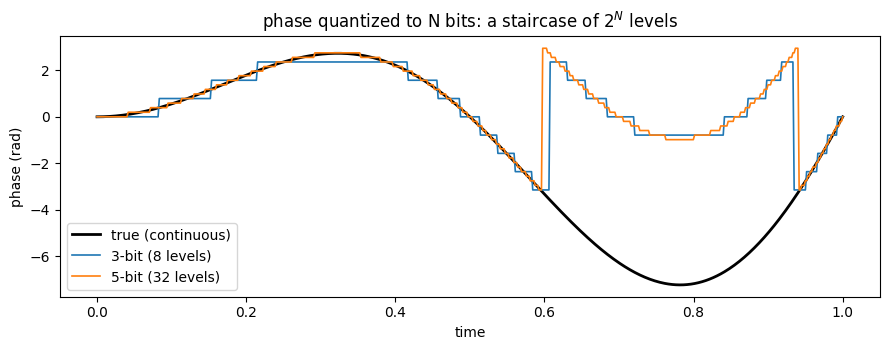

In [2]:
t = np.linspace(0, 1, 600)
phi = 3*np.pi*np.sin(2*np.pi*t) * t      # a smooth, wandering phase
plt.figure(figsize=(9, 3.6))
plt.plot(t, phi, "k", lw=2, label="true (continuous)")
for nb_ in (3, 5):
    plt.plot(t, quantize_phase(phi, nb_), lw=1.2, label=f"{nb_}-bit ({2**nb_} levels)")
plt.xlabel("time"); plt.ylabel("phase (rad)"); plt.legend()
plt.title("phase quantized to N bits: a staircase of $2^N$ levels")
plt.tight_layout(); plt.show()

## Disadvantage 1, quantified — 6 dB per bit, and never exact

Sweep the bit-depth: the RMS quantization error follows $\Delta/\sqrt{12}=\frac{2\pi}{2^N\sqrt{12}}$
exactly — it *halves with every added bit* (6 dB), but never reaches zero. A continuous phase can
only ever be approximated.

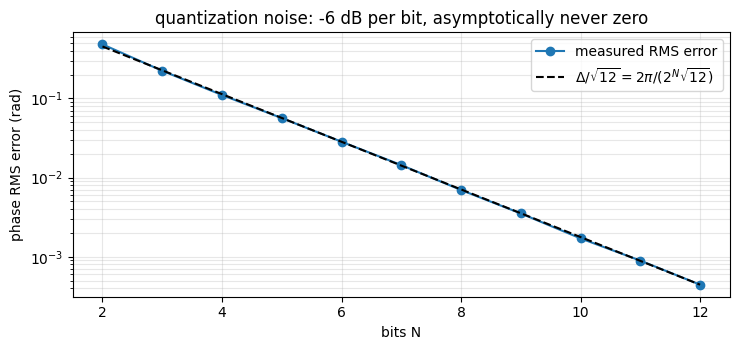

In [3]:
bits = np.arange(2, 13)
meas, theory = [], []
for n in bits:
    err = np.angle(np.exp(1j*(phi - quantize_phase(phi, n))))
    meas.append(np.sqrt(np.mean(err**2)))
    theory.append(2*np.pi / 2**n / np.sqrt(12))
plt.figure(figsize=(7.5, 3.6))
plt.semilogy(bits, meas, "o-", label="measured RMS error")
plt.semilogy(bits, theory, "k--", label=r"$\Delta/\sqrt{12}=2\pi/(2^N\sqrt{12})$")
plt.xlabel("bits N"); plt.ylabel("phase RMS error (rad)"); plt.legend()
plt.title("quantization noise: -6 dB per bit, asymptotically never zero")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## Disadvantage 2 — the wrap: a circle stored on a line

Phase is modulo $2\pi$, but a binary fixed-point number is linear. At the $-\pi/+\pi$ seam, two phases
that are physically *adjacent* are stored as numerically *opposite*. Subtract them naively and you get
$\sim2\pi$ of garbage; only the cyclic (wrapped) difference is correct.

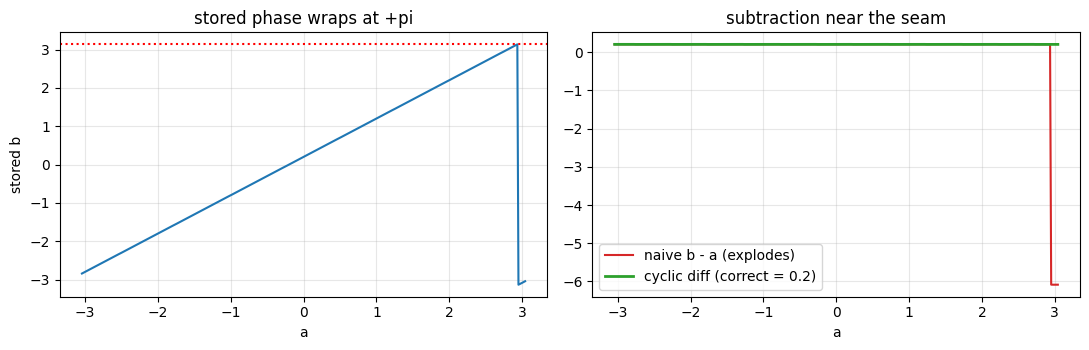

naive difference jumps by ~2pi at the wrap; the true difference stays 0.2 rad.


In [4]:
a = np.linspace(-np.pi+0.1, np.pi-0.1, 400)
b = a + 0.2                              # b is just 0.2 rad ahead of a
b_wrapped = quantize_phase(b, 12)        # stored in [-pi, pi): wraps past +pi
naive_diff = b_wrapped - a               # linear subtraction
true_diff = np.angle(np.exp(1j*(b_wrapped - a)))   # cyclic difference

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(a, b_wrapped, "C0"); ax[0].axhline(np.pi, color="r", ls=":")
ax[0].set_title("stored phase wraps at +pi"); ax[0].set_xlabel("a"); ax[0].set_ylabel("stored b")
ax[1].plot(a, naive_diff, "C3", label="naive b - a (explodes)")
ax[1].plot(a, true_diff, "C2", lw=2, label="cyclic diff (correct = 0.2)")
ax[1].set_title("subtraction near the seam"); ax[1].set_xlabel("a"); ax[1].legend()
for x in ax:
    x.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("naive difference jumps by ~2pi at the wrap; the true difference stays 0.2 rad.")

## Disadvantage 3 — ADC bits on $I_1,I_2$ cap the recovered phase

The phase is recovered from *digitised* intensities. Quantise $I_1,I_2$ to $N$-bit ADC values and run
Gerchberg-Saxton: below a handful of bits the recovery is wrecked, and it saturates once the ADC noise
floor drops below the algorithm's own. A real receiver buys phase accuracy with ADC bits.

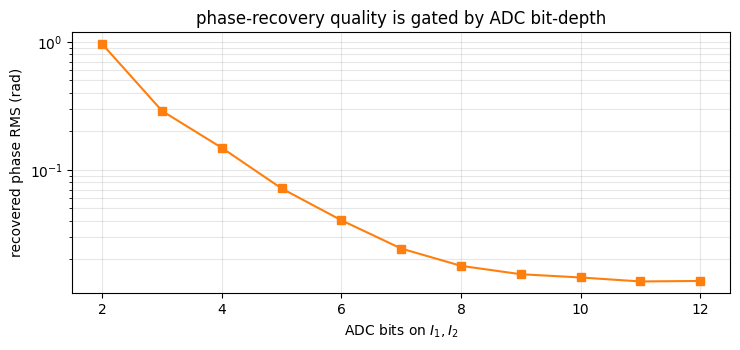

   2-bit ADC: phase RMS 0.961 rad
   3-bit ADC: phase RMS 0.289 rad
   4-bit ADC: phase RMS 0.149 rad
   5-bit ADC: phase RMS 0.071 rad
   6-bit ADC: phase RMS 0.040 rad
   7-bit ADC: phase RMS 0.024 rad
   8-bit ADC: phase RMS 0.018 rad
   9-bit ADC: phase RMS 0.015 rad
  10-bit ADC: phase RMS 0.014 rad
  11-bit ADC: phase RMS 0.013 rad
  12-bit ADC: phase RMS 0.014 rad


In [5]:
data = gs.make_qpsk_measurements(n_symbols=64, sps=8, D1=-5000.0, D2=-5750.0, snr_db=40.0)
phi_true, D1, D2 = data["phi_true"], data["D1"], data["D2"]
def align_rms(phi_rec):
    best = 1e9
    for s in (1, -1):
        off = np.angle(np.mean(np.exp(1j*(phi_true - s*phi_rec))))
        best = min(best, np.sqrt(np.mean(np.angle(np.exp(1j*(phi_true-(s*phi_rec+off))))**2)))
    return best

adc_bits = np.arange(2, 13)
rms = []
for n in adc_bits:
    I1q, I2q = adc(data["I1"], n), adc(data["I2"], n)
    phi_rec, _ = gs.retrieve_phase(I1q, I2q, D1, D2, n_iter=80, unit_amplitude=True)
    rms.append(align_rms(phi_rec))
plt.figure(figsize=(7.5, 3.6))
plt.semilogy(adc_bits, rms, "s-", color="C1")
plt.xlabel("ADC bits on $I_1, I_2$"); plt.ylabel("recovered phase RMS (rad)")
plt.title("phase-recovery quality is gated by ADC bit-depth"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for n, r in zip(adc_bits, rms):
    print(f"  {n:>2}-bit ADC: phase RMS {r:.3f} rad")

## Mitigations, and the engineering tradeoff

- **More bits** cost area, power, and ADC speed — and you only buy 6 dB each, so doubling precision
  is +1 bit, not free. Real systems pick the minimum bit-depth that clears the noise floor (here,
  ~8-10 bits is plenty; beyond that the SNR, not the quantiser, limits you).
- **Unwrap before you arithmetic.** Track $2\pi$ crossings (`np.unwrap`) or do all phase math with the
  cyclic difference $\arg(e^{i(\phi_a-\phi_b)})$, never the raw subtraction.
- **Gray code / dithering** soften the seam and decorrelate the quantization noise — standard tricks
  in encoders and ADCs.
- **The deeper point**: phase is the carrier of the information this whole project recovers, and it is
  a *continuous, cyclic* quantity forced through finite, linear binary hardware. Knowing the three
  disadvantages above is what lets you size the ADC and the fixed-point word length so the binary
  representation isn't the thing that loses the phase you worked to recover.